In [1]:
# Load Libraries
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import seaborn as sns;

pd.set_option('display.max_columns', None)

In [2]:
# Load the Dataset
df = pd.read_csv('secondary_data.csv', sep=';')
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,u,w,t,p,NaN,d,w


In [3]:
# Shape and Structure
print(f"Shape: {df.shape}")
df.info()

Shape: (61069, 21)
<class 'pandas.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  str    
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  str    
 3   cap-surface           46949 non-null  str    
 4   cap-color             61069 non-null  str    
 5   does-bruise-or-bleed  61069 non-null  str    
 6   gill-attachment       51185 non-null  str    
 7   gill-spacing          36006 non-null  str    
 8   gill-color            61069 non-null  str    
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   str    
 12  stem-surface          22945 non-null  str    
 13  stem-color            61069 non-null  str    
 14  veil-type             3177 non-null   str    
 15  veil-color 

## Data Understanding - Meaning and Type of Each Attribute

This dataset contains 21 attributes: 1 target binary variable labeled `class` and 20 predictor variables that describe physical attributes of each mushroom. Of the 20 predictors, 3 are continuous numeric measurements and 17 are categorical, each represented in the raw data as a single-letter code.

| Attribute | Type | Scale/Values | Description |
|---|---|---|---|
| `class` | Categorical (binary, target) | poisonous, edible | Whether the mushroom is safe to eat. "Poisonous" also includes mushrooms of unknown/not-recommended edibility. |
| `cap-diameter` | Continuous (numeric) | Float, cm | Width of the mushroom cap. |
| `cap-shape` | Categorical (nominal) | bell, conical, convex, flat, sunken, spherical, others | Overall shape of the cap. |
| `cap-surface` | Categorical (nominal) | fibrous, grooves, scaly, smooth, shiny, leathery, silky, sticky, wrinkled, fleshy | Texture of the cap surface. |
| `cap-color` | Categorical (nominal) | brown, buff, gray, green, pink, purple, red, white, yellow, blue, orange, black | Color of the cap. |
| `does-bruise-or-bleed` | Categorical (binary) | yes, no | Whether the mushroom's flesh visibly bruises or bleeds when damaged. |
| `gill-attachment` | Categorical (nominal) | adnate, adnexed, decurrent, free, sinuate, pores, none, unknown | How the gills attach to the stem. |
| `gill-spacing` | Categorical (nominal) | close, distant, none | How tightly packed the gills are. |
| `gill-color` | Categorical (nominal) | same color set as cap-color, plus none | Color of the gills. |
| `stem-height` | Continuous (numeric) | Float, cm | Height of the stem. |
| `stem-width` | Continuous (numeric) | Float, mm | Width (diameter) of the stem. |
| `stem-root` | Categorical (nominal) | bulbous, swollen, club, cup, equal, rhizomorphs, rooted | Shape/structure of the base of the stem. |
| `stem-surface` | Categorical (nominal) | same texture set as cap-surface, plus none | Texture of the stem surface. |
| `stem-color` | Categorical (nominal) | same color set as cap-color | Color of the stem. |
| `veil-type` | Categorical (nominal) | partial, universal | Type of veil (a protective membrane) present on the mushroom. |
| `veil-color` | Categorical (nominal) | same color set as cap-color | Color of the veil, if present. |
| `has-ring` | Categorical (binary) | yes, no | Whether the mushroom has a ring (remnant of a partial veil) on the stem. |
| `ring-type` | Categorical (nominal) | cobwebby, evanescent, flaring, grooved, large, pendant, sheathing, zone, scaly, movable, none, unknown | Type of ring present, if any. |
| `spore-print-color` | Categorical (nominal) | same color set as cap-color (excluding black in some sources) | Color of the mushroom's spore print, obtained by placing the cap gill-side down. |
| `habitat` | Categorical (nominal) | grasses, leaves, meadows, paths, heaths, urban, waste, woods | Environment where the mushroom was found. |
| `season` | Categorical (nominal) | spring, summer, autumn, winter | Season in which the mushroom was recorded. |

This information was gathered through the `primary_data_meta.txt` file contained in the ZIP download on the UCI Machine Learning Repository. Here are a few notes regarding the interpretation of the table above:

- **Nominal vs. Ordinal:** All categorical attributes here are nominal (unordered) rather than ordinal. There is no inherent ranking between, say, "bell" and "convex" cap shapes or with any other nominal attribute.
- **Shared Value Sets:** Several attributes here (`gill-color`, `stem-color`, `veil-color`, `spore-print-color`) reuse the same 12 color palette that `cap-color` has. This appears to be a deliberate design choice by the dataset creators to keep color encoding consistent across variables that measure color.
- **"None" as a valid category:** For attributes like `gill-spacing`, `stem-surface` and `ring-type`, the value "none" itself is a meaningful category that determines a mushroom to be lacking in a certain categorical attribute. This will be treated differently to 'NaN' values, which are indeed missing values. 
- **Units differ between the two continuous stem measurements:** `stem-height` is recorded in centimeters (cm), while `stem-width` is recorded in millimeters (mm). The unit differences are worth taking into consideration when comparing the two attributes directly. Because they're not on the same scale, `stem-width` values will naturally look larger than `stem-height` values for a well-proportioned mushroom.

In [4]:
# Class Balance Table
print("Class counts:")
print(df['class'].value_counts())
print("\nClass Proportions:")
print(df['class'].value_counts(normalize=True).round(3))

Class counts:
class
p    33888
e    27181
Name: count, dtype: int64

Class Proportions:
class
p    0.555
e    0.445
Name: proportion, dtype: float64


## Class Balance

The classes are reasonably balanced (55.5% poisonous, 44.5% edible). A naive model that always predicts "poisonous" would achieve a 55.4% accuracy rate. Since the split isn't heavily imbalanced, accuracy alone would be a misleading metric here than it would be for an imbalanced dataset - though sensitivity to the poisonous class will still be prioritized over raw accuracy, as previously discussed in the Business Understanding section.

In [5]:
# Check for Duplicates
duplicate_count = df.duplicated().sum()
print(f"Exact duplicate rows: {duplicate_count}")
print(f"Percentage of dataset: {(duplicate_count / len(df) * 100):.2f}%")

Exact duplicate rows: 146
Percentage of dataset: 0.24%


In [6]:
# Inspect Duplicates
dupes = df[df.duplicated(keep=False)]
print(f"Total rows involved in duplication: {len(dupes)}")

dupes_sorted = dupes.sort_values(by=list(df.columns))
dupes_sorted.head(20)

Total rows involved in duplication: 266


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
12712,p,0.72,x,g,y,f,NaN,NaN,y,3.51,0.77,NaN,NaN,y,NaN,NaN,f,f,NaN,d,u
12978,p,0.72,x,g,y,f,NaN,NaN,y,3.51,0.77,NaN,NaN,y,NaN,NaN,f,f,NaN,d,u
9670,p,1.14,x,g,w,f,a,d,w,3.13,1.78,NaN,NaN,e,NaN,NaN,f,f,NaN,d,u
9863,p,1.14,x,g,w,f,a,d,w,3.13,1.78,NaN,NaN,e,NaN,NaN,f,f,NaN,d,u
57981,p,2.43,o,l,g,f,f,f,f,0.00,0.00,f,f,f,NaN,NaN,f,f,NaN,d,w
57987,p,2.43,o,l,g,f,f,f,f,0.00,0.00,f,f,f,NaN,NaN,f,f,NaN,d,w
58048,p,2.44,o,l,g,f,f,f,f,0.00,0.00,f,f,f,NaN,NaN,f,f,NaN,d,s
58197,p,2.44,o,l,g,f,f,f,f,0.00,0.00,f,f,f,NaN,NaN,f,f,NaN,d,s
58207,p,2.45,o,l,g,f,f,f,f,0.00,0.00,f,f,f,NaN,NaN,f,f,NaN,d,u
58218,p,2.45,o,l,g,f,f,f,f,0.00,0.00,f,f,f,NaN,NaN,f,f,NaN,d,u


In [7]:
# Drop the Duplicates
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]
print(f"Rows dropped: {before - after}")
print(f"New shape after dropping exact duplicates: {df.shape}")

Rows dropped: 146
New shape after dropping exact duplicates: (60923, 21)


## Data Quality - Addressing Duplicate Data

We checked for exact duplicate rows using `df.duplicated()`, and through that, we found 146 dupicate rows (0.24% of the entire dataset). Before dropping them, we inspected the actual duplicate rows to confirm they were genuine duplicates rather than coincidentally similar mushrooms (e.g. two different mushrooms happen to share a similar cap-diameter, but differ in other measurements). Every duplicate row matched its pair exactly across not just all the numeric measurements, but across every categorical attribute as well. 

With this level of agreement across all independent attributes, it's extremely unlikely that duplicate data happens to be coincidental. This pattern is far more consistent with genuine duplication.

## Decision

These 146 duplicate rows were dropped using the code `drop_duplicates()`. At only 0.24% of the entire dataset, dropping these rows doesn't meaningfully affect the class balance between edible and poisonous mushrooms, and removing them actually ensures every subsequent calculation reflects distinct observations rather than double-counted ones. The new total amount of observations after dropping exact duplicates is now 60,923.

In [8]:
# Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
veil-type,57746,94.79
spore-print-color,54597,89.62
veil-color,53510,87.83
stem-root,51536,84.59
stem-surface,38122,62.57
gill-spacing,25062,41.14
cap-surface,14120,23.18
gill-attachment,9855,16.18
ring-type,2471,4.06


In [9]:
# Investigating zero stem height / width
zero_stem = df[(df['stem-height'] == 0) | (df['stem-width'] == 0)] 
print(f"Rows with stem-height or stem-width == 0: {len(zero_stem)}")
print(f"Percentage of dataset: {(len(zero_stem) / len(df) * 100):.2f}%")

print("\nClass breakdown (Poisonous vs Edible) for these rows:")
print(zero_stem['class'].value_counts(normalize=True).round(3))

print("\nOverall class breakdown for comparison:")
print(df['class'].value_counts(normalize=True).round(3))

print("\nCap-shape breakdown for these rows:")
print(zero_stem['cap-shape'].value_counts())

Rows with stem-height or stem-width == 0: 915
Percentage of dataset: 1.50%

Class breakdown (Poisonous vs Edible) for these rows:
class
p    1.0
Name: proportion, dtype: float64

Overall class breakdown for comparison:
class
p    0.554
e    0.446
Name: proportion, dtype: float64

Cap-shape breakdown for these rows:
cap-shape
o    915
Name: count, dtype: int64


In [10]:
# Do mushrooms that have cap-shape == 'o' only classify as poisonous?
print(df[df['cap-shape'] == 'o']['class'].value_counts())

class
p    2491
e     825
Name: count, dtype: int64


## Data Quality - Inspecting Missing Values and "Zero" Stem Measurements
Nine attributes in this dataset contain missing values - namely `veil-type` (94.79% missing), `spore-print-color` (89.62% missing), `veil-color` (87.83% missing), `stem-root` (84.59% missing), `stem-surface` (62.57% missing), `gill-spacing` (41.14% missing), `cap-surface` (23.18%), `gill-attachment` (16.18%), and `ring-type` (4.06%). With a substantial lack of information in some of these attributes, it's worth considering whether they should be included when building out our model, or whether missingness carries useful information in this context. 

While investigating the dataset for missing values and data quality issues, we noticed that `stem-height` and `stem-width` are both recorded as exactly 0.00 in 915 rows (1.50% of the dataset). Initially, we assumed that these were placeholder values indicating a data entry or measurement error.

Upon further investigation, we found that all 915 rows share a similar cap-shape ('o'). All 915 rows classify as poisonous too, according to the class breakdown output where the proportion of poisonous (p) was 1.0 (100%) for these specific rows. However, based on this observation, we cannot claim that `cap-shape` is a perfect predictor of toxicity. Across the full dataset, 3,316 mushrooms share this `cap-shape`, and 2,491 of them are poisonous while 825 are edible. This means that 825 edible 'o'-shaped mushrooms all have non-zero stem measurements, while the poisonous subset is split between those without stems (915) and those with stems (1,576).

## Relationship Between Lack of Stem and Class
The zero values found with `stem-height` and `stem-width` reflect a real biological trait (lack of a stem) found in some species of mushrooms. Within the `cap-shape == 'o'` group specifically, the **absence of a stem** appears to be **strongly associated** with the **poisonous class**, more so than `cap-shape` alone. This finding suggests that stem presence or absence could be a useful binary feature that we engineer (e.g. a 'has-stem' flag) when moving into the modeling phase of the project.

## Decision
These rows will be kept rather than deleted from the dataset, and their zero-values will be kept as-is. Imputing or removing them would discard genuinely useful and predictive information about a mushroom's toxicity.

This decision extends to the highly-missing categorical attributes above. Columns like `veil-type` and `stem-root` likely reflect genuine biological absence (e.g., a species that is genetically incapable of developing a veil) rather than data collection errors, similar to what was found in the zero-stem pattern. Right now, we plan to retain these missing 'NaN' values rather than imputing them, and we'll consider encoding missingness itself as an informative feature during modeling rather than dropping these columns completely.

In [11]:
# IQR-based Outlier Detection
def iqr_outlier_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

for col in ['cap-diameter', 'stem-height', 'stem-width']:
    lower, upper = iqr_outlier_bounds(df[col])
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: bounds = ({lower:.2f}, {upper:.2f}) | outliers = {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)") 

cap-diameter: bounds = (-4.10, 16.14) | outliers = 2389 (3.92%)
stem-height: bounds = (0.00, 12.40) | outliers = 4084 (6.70%)
stem-width: bounds = (-11.74, 33.57) | outliers = 1980 (3.25%)


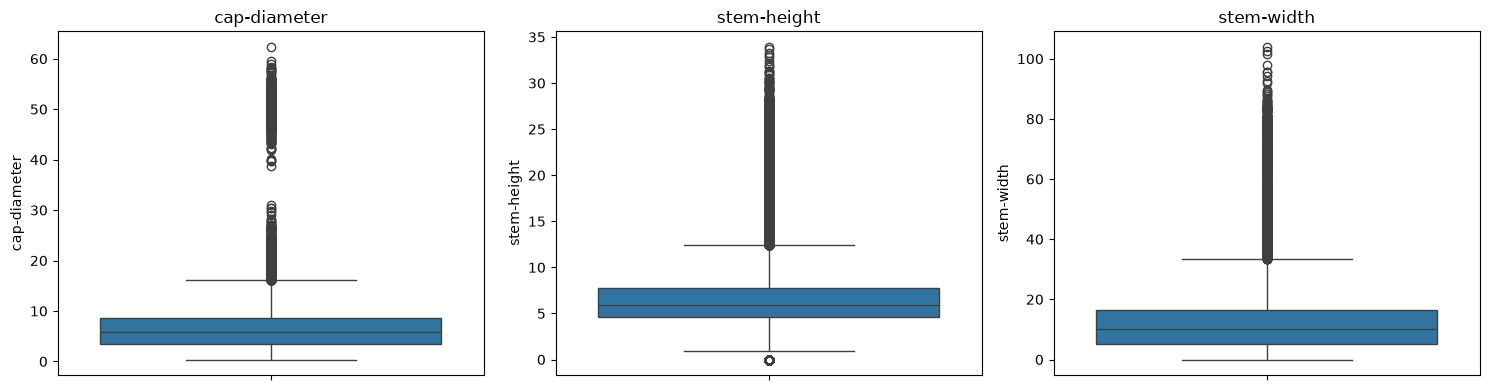

In [12]:
# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['cap-diameter', 'stem-height', 'stem-width']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Data Quality - Outliers in Numeric Attributes

We examined the three continuous numeric attributes (`cap-diameter`, `stem-height`, `stem-width`) for outliers using IQR-based calculations (numeric confirmation) and boxplots (visual confirmation).

All three continuous attributes showed a similar shape and pattern: a long right-tail with high values and no meaningful outliers on the lower end (aside from the zero-values discussed earlier with `stem-height` and `stem-width`, which were already flagged as a legitimate biological feature and likely not an error). Notably, the high-end outliers form a gradually thinning distribution rather than a small cluster of isolated high values. This right-skewed distribution can be observed in the summary statistics table for all three numeric attributes as well. The gap between the mean value and the max value, as well as the variance, for each attribute is extremely large, indicating the presence of extreme outliers without looking at visualizations of the data.

## Interpretation

Since this dataset simulates mushrooms coming from 173 distinct real species, it's reasonable to expect meaningful size variation across different species. There are some species that are genuinely larger than the "typical" mushroom. However, it's worth noting that the 'secondary_data.csv' file doesn't include the species or family identifier of each individual mushroom. Only 'primary_data.csv' records species-level information (as 173 rows with range-based attribute values), but there is no shared key linking the two data files at the individual mushroom level. As a result, we cannot confirm which species each mushroom - or any specific outlier mushroom - belongs to. We determined this choice to be intentional for the dataset's overall purpose: someone who encounters a mushroom out in the wild similarly would not know the species in advance (unless they had expert knowledge in this field, but this would be a rare scenario). Therefore, they must rely on observable physical traits (the same ones captured in this dataset) to know whether the mushroom would be safe to eat.

## Data Quality Decision

These outliers will not be removed from the dataset. Doing so would discard real observations of larger mushroom species rather than correcting an error, and it could bias any model against correctly recognizing genuinely large mushrooms.

In [13]:
# Summary Stats for Numeric Columns
df[['cap-diameter', 'stem-height', 'stem-width']].describe()

,cap-diameter,stem-height,stem-width
count,60923.000000,60923.000000,60923.000000
mean,6.741957,6.597202,12.178484
std,5.268435,3.358757,10.030361
min,0.380000,0.000000,0.000000
25%,3.490000,4.650000,5.250000
50%,5.880000,5.960000,10.220000
75%,8.550000,7.750000,16.580000
max,62.340000,33.920000,103.910000


In [14]:
# Descriptive Stats for Numeric Attributes
numeric_cols = ['cap-diameter', 'stem-height', 'stem-width']

stats = pd.DataFrame({
    'mean': df[numeric_cols].mean(),
    'median': df[numeric_cols].median(),
    'mode': df[numeric_cols].mode().iloc[0],
    'variance': df[numeric_cols].var(),
    'std_dev': df[numeric_cols].std(),
    'range': df[numeric_cols].max() - df[numeric_cols].min(),
    'min': df[numeric_cols].min(),
    'max': df[numeric_cols].max()
})
stats.round(2)

,mean,median,mode,variance,std_dev,range,min,max
cap-diameter,6.74,5.88,3.18,27.76,5.27,61.96,0.38,62.34
stem-height,6.60,5.96,0.00,11.28,3.36,33.92,0.00,33.92
stem-width,12.18,10.22,0.00,100.61,10.03,103.91,0.00,103.91


## Simple Statistics: Numeric Attributes

We calculated the mean, median, mode, range, standard deviation and variance for the three numeric attributes to summarize their distributions.

The mean is higher than the median for all three attributes, which suggests a right-skewed distribution shape that we can later confirm with histograms. The mode of 0.00 for both `stem-height` and `stem-width` reflects the 915 rows consisting of the "stemless" subpopulation identified earlier in our data quality investigation. This doesn't suggest, however, that mushrooms tend to lack a stem. What the mode represents in this context is the single most repeated exact value in each column, which happens to be 0.00. Other non-zero measurements tend to have slight variations, so it makes sense why we see 0.00 as the mode for the stem measurement columns.

`stem-width` shows the largest variance (100.61) and standard deviation (10.03) of the three attributes, meaning stem width varies the most across the dataset. This finding is consistent with the fact that this dataset simulates mushrooms from 173 distinct species, some with thinner or thicker stems than others.

These summary statistics are significant to our analysis, because they establish a baseline understanding of "typical" mushroom size in this dataset before we explore how these attributes relate to our target class variable, as well as other physical attributes in this dataset.

In [15]:
# Recoding Attribute Values for Simplicity of Analysis
# This code was derived using the help of the 'primary_data_meta.txt' file included in the ZIP download for the dataset on the UCI Machine Learning Repository. 
# This file contains information on what each letter in each categorical attribute (and the class target variable) stands for.

decode_map = {
    'class': {'p': 'poisonous', 'e': 'edible'},
    'cap-shape': {'b': 'bell', 'c': 'conical', 'x': 'convex', 'f': 'flat',
                  's': 'sunken', 'p': 'spherical', 'o': 'others'},
    'cap-surface': {'i': 'fibrous', 'g': 'grooves', 'y': 'scaly', 's': 'smooth',
                    'h': 'shiny', 'l': 'leathery', 'k': 'silky', 't': 'sticky',
                    'w': 'wrinkled', 'e': 'fleshy'},
    'cap-color': {'n': 'brown', 'b': 'buff', 'g': 'gray', 'r': 'green', 'p': 'pink',
                  'u': 'purple', 'e': 'red', 'w': 'white', 'y': 'yellow',
                  'l': 'blue', 'o': 'orange', 'k': 'black'},
    'does-bruise-or-bleed': {'t': 'bruises-or-bleeding', 'f': 'no'},
    'gill-attachment': {'a': 'adnate', 'x': 'adnexed', 'd': 'decurrent', 'e': 'free',
                        's': 'sinuate', 'p': 'pores', 'f': 'none', '?': 'unknown'},
    'gill-spacing': {'c': 'close', 'd': 'distant', 'f': 'none'},
    'gill-color': {'n': 'brown', 'b': 'buff', 'g': 'gray', 'r': 'green', 'p': 'pink',
                   'u': 'purple', 'e': 'red', 'w': 'white', 'y': 'yellow',
                   'l': 'blue', 'o': 'orange', 'k': 'black', 'f': 'none'},
    'stem-root': {'b': 'bulbous', 's': 'swollen', 'c': 'club', 'u': 'cup',
                  'e': 'equal', 'z': 'rhizomorphs', 'r': 'rooted'},
    'stem-surface': {'i': 'fibrous', 'g': 'grooves', 'y': 'scaly', 's': 'smooth',
                     'h': 'shiny', 'l': 'leathery', 'k': 'silky', 't': 'sticky',
                     'w': 'wrinkled', 'e': 'fleshy', 'f': 'none'},
    'stem-color': {'n': 'brown', 'b': 'buff', 'g': 'gray', 'r': 'green', 'p': 'pink',
                   'u': 'purple', 'e': 'red', 'w': 'white', 'y': 'yellow',
                   'l': 'blue', 'o': 'orange', 'k': 'black', 'f': 'none'},
    'veil-type': {'p': 'partial', 'u': 'universal'},
    'veil-color': {'n': 'brown', 'b': 'buff', 'g': 'gray', 'r': 'green', 'p': 'pink',
                   'u': 'purple', 'e': 'red', 'w': 'white', 'y': 'yellow',
                   'l': 'blue', 'o': 'orange', 'k': 'black', 'f': 'none'},
    'has-ring': {'t': 'ring', 'f': 'none'},
    'ring-type': {'c': 'cobwebby', 'e': 'evanescent', 'r': 'flaring', 'g': 'grooved',
                  'l': 'large', 'p': 'pendant', 's': 'sheathing', 'z': 'zone',
                  'y': 'scaly', 'm': 'movable', 'f': 'none', '?': 'unknown'},
    'spore-print-color': {'n': 'brown', 'b': 'buff', 'g': 'gray', 'r': 'green', 'p': 'pink',
                          'u': 'purple', 'e': 'red', 'w': 'white', 'y': 'yellow',
                          'l': 'blue', 'o': 'orange', 'k': 'black'},
    'season': {'s': 'spring', 'u': 'summer', 'a': 'autumn', 'w': 'winter'},
    'habitat': {'g': 'grasses', 'l': 'leaves', 'm': 'meadows', 'p': 'paths',
                'h': 'heaths', 'u': 'urban', 'w': 'waste', 'd': 'woods'}
}

df_decoded = df.copy()
for col, mapping in decode_map.items():
    df_decoded[col] = df_decoded[col].map(mapping)

df_decoded[['class', 'cap-shape', 'season', 'habitat']].head()

,class,cap-shape,season,habitat
0,poisonous,convex,winter,woods
1,poisonous,convex,summer,woods
2,poisonous,convex,winter,woods
3,poisonous,flat,winter,woods
4,poisonous,convex,winter,woods


In [16]:
# Mode / Count for three of the Key Categorical Attributes 
for col in ['cap-shape', 'habitat', 'season']:
    print(f"\n{col} value counts and percentages:")
    counts = df_decoded[col].value_counts()
    pcts = df_decoded[col].value_counts(normalize=True).mul(100).round(1)
    summary = pd.DataFrame({'count': counts, 'pct': pcts})
    display(summary)
    print(f"Mode: {df_decoded[col].mode()[0]}")


cap-shape value counts and percentages:


,count,pct
cap-shape,,
convex,26932,44.2
flat,13404,22.0
sunken,7164,11.8
bell,5694,9.3
others,3316,5.4
spherical,2598,4.3
conical,1815,3.0


Mode: convex

habitat value counts and percentages:


,count,pct
habitat,,
woods,44063,72.3
grasses,7943,13.0
leaves,3168,5.2
meadows,2920,4.8
heaths,2001,3.3
paths,360,0.6
waste,353,0.6
urban,115,0.2


Mode: woods

season value counts and percentages:


,count,pct
season,,
autumn,30141,49.5
summer,22850,37.5
winter,5233,8.6
spring,2699,4.4


Mode: autumn


## Observations based on Key Categorical Attributes 

**cap-shape**: The most common cap shape is convex (n = 26,932, 44.2% of the dataset), followed by flat (n = 13,404). The "others" shape - the shape associated with our stemless and poisonous association finding - makes up a relatively small part of the dataset at 5.4% (n = 3,316).

**habitat**: The overwhelming majority of mushrooms in this dataset were found in the woods (n = 44,063, 72.3%), far more than any other habitat type. This makes intuitive sense, as woodlands are typically the richest environment for fungal growth due to decaying organic matter. 

**season**: Most mushrooms were recorded in the autumn (n = 30,141, 49.5%), followed by summer (n = 22,850, 37.5%). Autumn is widely considered peak mushroom growth season in many climates due to cooling temperatures and moisture following summer growth.

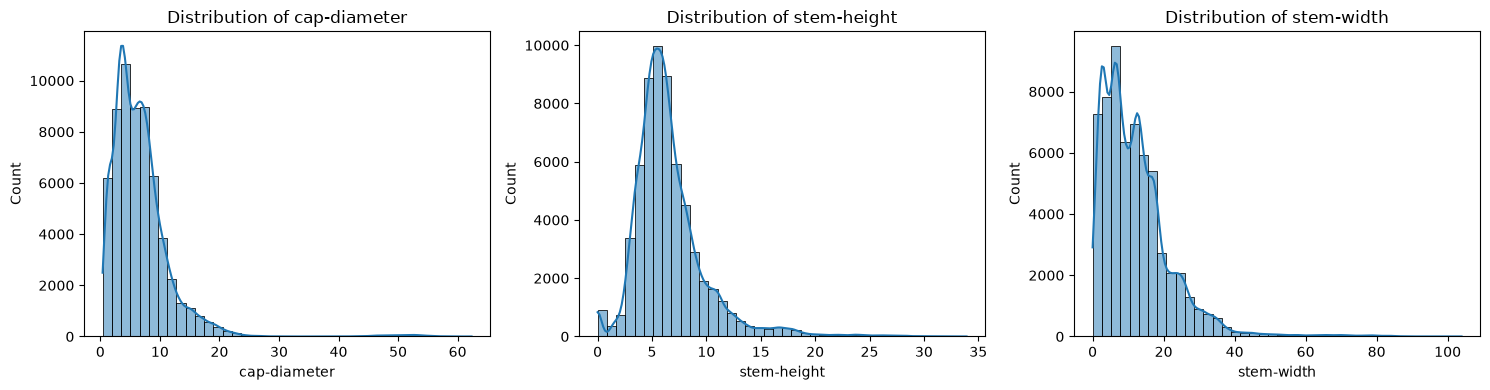

In [17]:
# Histograms 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['cap-diameter', 'stem-height', 'stem-width']):
    sns.histplot(df[col], bins=40, ax=ax, kde=True)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

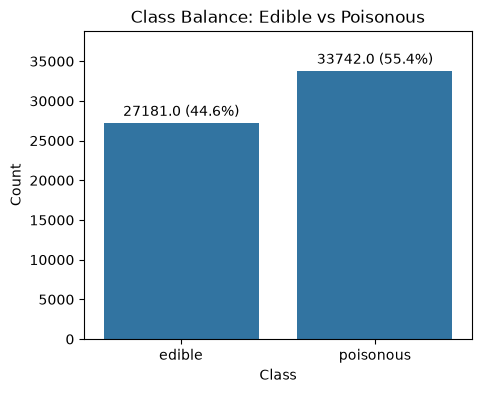

In [18]:
# Class Balance Bar Chart
plt.figure(figsize=(5, 4))
ax = sns.countplot(data=df_decoded, x='class', order=['edible', 'poisonous'])

total = len(df_decoded)
for container in ax.containers:
    labels = [f'{count} ({count/total*100:.1f}%)' for count in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3)

plt.title('Class Balance: Edible vs Poisonous')
plt.xlabel('Class')
plt.ylabel('Count')
plt.ylim(0, df_decoded['class'].value_counts().max() * 1.15)
plt.show()

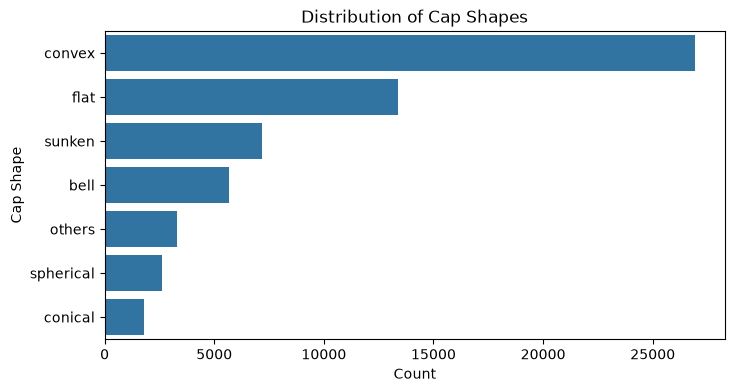

In [19]:
# Bar Chart for Cap Shape
plt.figure(figsize=(8,4))
order = df_decoded['cap-shape'].value_counts().index
sns.countplot(data=df_decoded, y='cap-shape', order=order)
plt.title('Distribution of Cap Shapes')
plt.xlabel('Count')
plt.ylabel('Cap Shape')
plt.show()

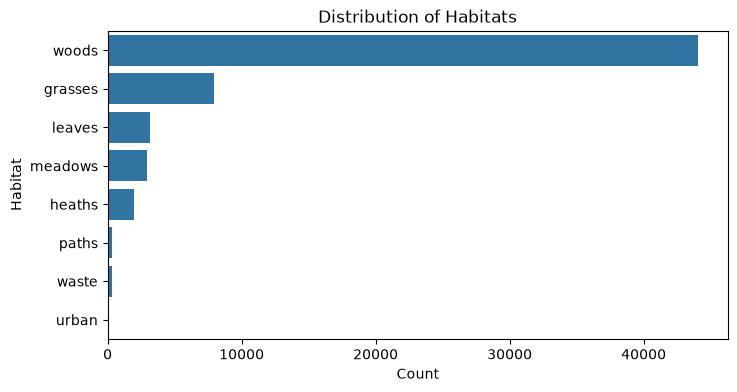

In [20]:
# Bar Chart for Habitat
plt.figure(figsize=(8, 4))
order = df_decoded['habitat'].value_counts().index
sns.countplot(data=df_decoded, y='habitat', order=order)
plt.title('Distribution of Habitats')
plt.xlabel('Count')
plt.ylabel('Habitat')
plt.show()

## Visualizations of Attributes 

### Distribution of Numeric Attributes (Histograms)

Histograms were used with a kernal density overlay to visualize the shape of `cap-diameter`, `stem-height`, and `stem-width`. A histogram is the appropriate choice since these are continuous numeric variables, and the goal of these visualizations is to see the overall shape of the distribution rather than counts as with discrete variables. 

All three distributions are right-skewed, as we already had observed through the boxplots of these same three variables. Each distribution has a long tail of larger values, which confirms the mean > median relationship observed through the summary statistics. Both `cap-diameter` and `stem-width` show a subtle bimodal pattern (a small secondary bump before hitting the main peak), which suggests that there may be two loosely overlapping subpopulations of mushroom sizes within the entire population in this dataset. This is consistent with the fact that these values are simulated from 173 distinct species, so some are smaller or larger than others. `stem-height` shows a small spike right at 0, which corresponds to the 915 "stemless" mushrooms identified in the data quality investigation.

### Class Balance Bar Chart

A bar chart is well suited to a binary categorical variable like `class`, since it directly compares the count of two discrete classes. The chart confirms the roughly 55/45 split (poisonous/edible) found in the Simple Statistics section. The classes are imbalanced enough to be worth noting, but they're not so imbalanced that it renders metrics like accuracy meaningless.

### Distribution of Cap Shape (Horizontal Bar Chart)

A horizontal bar chart was used to compare the different groups within the `cap-shape` attribute. This chart confirms that 'convex' is the dominant cap shape (44.2% of the dataset), with 'others' - the shape confirmed to be tied to our earlier finding of the association between stemless and poisonous mushrooms - appearing far less frequently (5.4% of the dataset), toward the lower end of the distribution.

### Distribution of Habitat (Horizontal Bar Chart)

Similar to what was done with `cap-shape`, a horizontal bar chart was used to compare the different habitats recorded in this dataset. This chart confirms that 'woods' is by far the dominant habitat for mushrooms recorded in this dataset. Though fungi can grow in a variety of environments (tropical, arctic, aquatic, etc.), it appears that for most of the species recorded in this specific dataset, they thrive in forest environments with rich soil in organic matter. This chart sets up the cross-tabulation between habitat and cap shape explored later in this report, where we look at how cap shape varies across these habitat categories.

              cap-diameter  stem-height  stem-width
cap-diameter         1.000        0.422       0.695
stem-height          0.422        1.000       0.433
stem-width           0.695        0.433       1.000


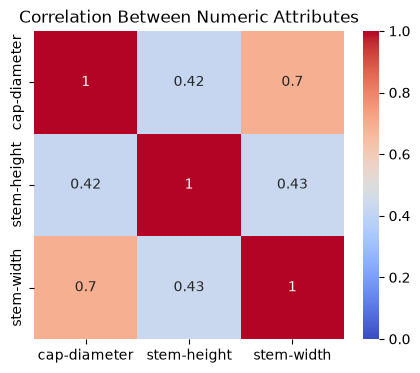

In [21]:
# Correlation Matrix - Relationships Between Continuous Attributes
corr = df[['cap-diameter', 'stem-height', 'stem-width']].corr()
print(corr.round(3))

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title('Correlation Between Numeric Attributes')
plt.show()

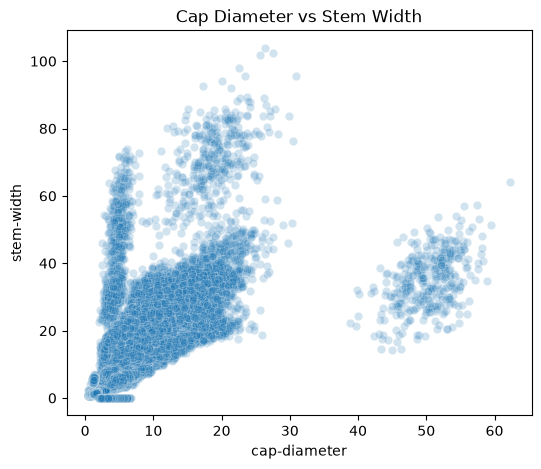

In [22]:
# Scatterplot for Strongest Pair
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='cap-diameter', y='stem-width', alpha=0.2)
plt.title('Cap Diameter vs Stem Width')
plt.show()

In [23]:
# Cross-tabulation between cap shape and habitat
# (A method to measure the frequency of categorical combinations)
crosstab = pd.crosstab(df_decoded['cap-shape'], df_decoded['habitat'], normalize='index').round(3)
crosstab

habitat,grasses,heaths,leaves,meadows,paths,urban,waste,woods
cap-shape,,,,,,,,
bell,0.314,0.022,0.011,0.112,0.000,0.000,0.000,0.541
conical,0.192,0.028,0.129,0.000,0.051,0.000,0.000,0.600
convex,0.133,0.037,0.034,0.028,0.000,0.000,0.006,0.762
flat,0.105,0.030,0.085,0.063,0.007,0.004,0.013,0.693
others,0.000,0.000,0.038,0.000,0.053,0.000,0.000,0.909
spherical,0.109,0.000,0.052,0.251,0.000,0.023,0.000,0.565
sunken,0.076,0.060,0.078,0.004,0.000,0.000,0.000,0.782


## Relationship Between Attributes

### Correlation Matrix

We computed a Pearson's correlation matrix across the three numeric attributes in the dataset and visualized it as a heatmap. `cap-diameter` and `stem-width` show the strongest relationship (r = 0.695, a moderately strong positive correlation), while `stem-height` correlates more weakly with the other (r = 0.42 & 0.43). Biologically, this observation makes sense. Mushrooms that have wider caps tend to have wider stems to support them, but the height of the mushroom's stem is independent of that. Height is likely more driven by species and environment rather than by overall mushroom "size".

### Cap Diameter vs. Stem Width Scatterplot

Given the strong correlation between `cap-diameter` and `stem-width`, we visualized their relationship directly with a scatterplot. Rather than one smooth trend, the data actually forms two visually distinct clusters: a dense main group and an isolated, smaller cluster of much larger mushrooms. We investigate this smaller cluster further in the next cell.

### Cross-Tabulation: Cap Shape vs. Habitat

We cross-tabulated `cap-shape` against `habitat` to see whether certain cap shapes cluster in certain environments. 'Woods' is the dominant habitat across every shape, but the "others" cap shape stood out the most. 90.9% of "others"-shaped mushrooms occur specifically in the woods, the highest concentration of any cap shape. This shape never appears in grasses, heaths, meadows, urban or waste lands. Combined with our earlier findings on "others"-shaped mushrooms, this suggests that this category of cap shape may represent a small number of specific woodland species of mushrooms.

In [24]:
# Investigating large diameter cluster
large_cluster = df_decoded[df_decoded['cap-diameter'] > 35]
print(f"Rows in large-diameter cluster: {len(large_cluster)}")

print("\nCap-Shape Breakdown:")
print(large_cluster['cap-shape'].value_counts())

print("\nClass Breakdown:")
print(large_cluster['class'].value_counts())
print(large_cluster['class'].value_counts(normalize=True).round(3))

Rows in large-diameter cluster: 353

Cap-Shape Breakdown:
cap-shape
others    353
Name: count, dtype: int64

Class Breakdown:
class
edible    353
Name: count, dtype: int64
class
edible    1.0
Name: proportion, dtype: float64


## Follow-up: The Large Diameter Cluster

On the scatterplot visualizing the relationship between `cap-diameter` and `stem-width`, we noticed a small cluster of observations with a cap diameter greater than 35 cm. Investigating this cluster further lead us to discover that there are 353 rows in the dataset that have a cap diameter greater than 35 cm, and 100% of these 353 mushrooms have an "others" cap-shape and are classed as edible. 

Based on all the findings concerning this specific cap-shape, "others" appears to not be a uniform category. It contains two distinct, internally consistent sub-groups with opposite toxicity outcomes: a small-bodied, stemless group that is always poisonous, and a large bodied (cap-diameter > 35) group that is always edible. The remaining "other"-shaped mushrooms (roughly 2,048) fall outside both of these extremes and show more mixed-class outcomes.

This reinforces the point made earlier that `cap-shape` alone is a weak predictor of toxicity. However, `cap-shape` combined with size or stem measurement variables captures much more specific patterns. This variable is a strong candidate for engineered interaction features (e.g. a combined `cap-shape` + `stem-presence` or `cap-shape` + `size-values` feature) rather than relying on `cap-shape` as a standalone attribute. 

In [25]:
# Group-wise averages by class
group_stats = df_decoded.groupby('class')[['cap-diameter', 'stem-height', 'stem-width']].agg(['mean', 'median'])
group_stats.round(2)

cap-diameter        stem-height        stem-width       
                  mean median        mean median       mean median
class                                                             
edible            7.80   6.71        7.04   6.24      14.36  12.59
poisonous         5.89   5.00        6.24   5.64      10.42   7.70

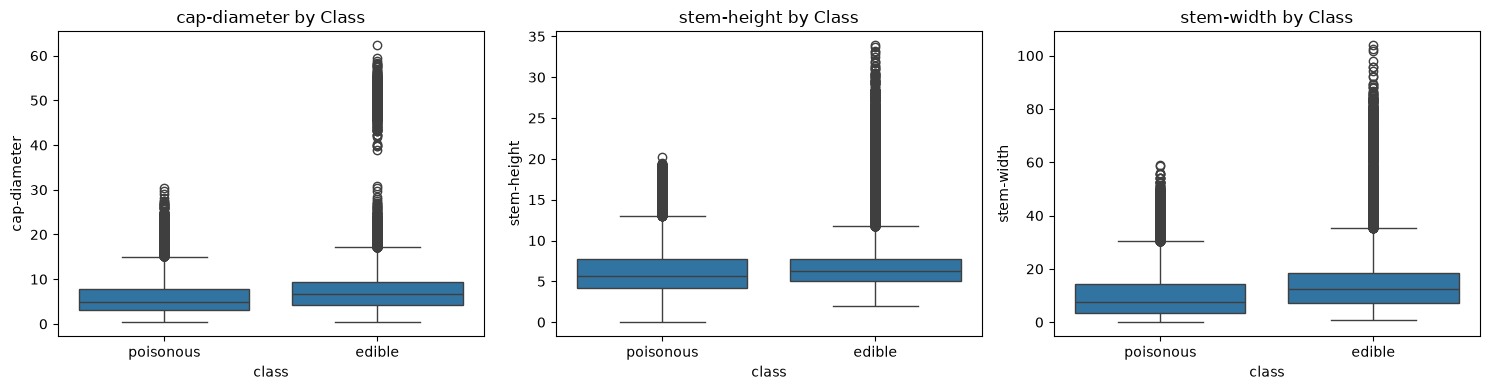

In [26]:
# Boxplots Split by Class
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['cap-diameter', 'stem-height', 'stem-width']):
    sns.boxplot(data=df_decoded, x='class', y=col, ax=ax)
    ax.set_title(f'{col} by Class')
plt.tight_layout()
plt.show()

## General Size Relationship with Class

Beyond the cap-shape-specific patterns identified earlier, the next step we took was to check whether mushroom size overall differed by class using group-wise averages and boxplots split by class.

Across all three continuous attributes, edible mushrooms are consistently larger on average (on both mean and median) than poisonous mushrooms. This gap is the most pronounced in the `stem-width` plot (medians of 12.59 vs. 7.70). Looking at the `stem-width` boxplot, the edible box sits slightly higher than the poisonous box, and the extreme high-end outliers (including the large diameter cluster identified earlier, which was 100% edible) are almost entirely on the edible side. The `cap-diameter` plot shows similar patterns, while it's a little less pronounced but still detectable with the `stem-height` plot. 

Larger mushrooms in this dataset tend to be classified as edible, and smaller mushrooms tend to be poisonous. This is a useful complement to the more specific, shape-dependent patterns found earlier (e.g., "others"-shaped, stemless mushrooms being poisonous), since it shows that size carries predictive power even without conditioning on cap-shape.

In [27]:
# Engineering a 'has-stem' attribute
df_decoded['has-stem'] = ~((df['stem-height'] == 0) & (df['stem-width'] == 0))
df_decoded['has-stem'] = df_decoded['has-stem'].map({True: 'yes', False: 'no'})

print(df_decoded.groupby('has-stem')['class'].value_counts(normalize=True).round(3))

has-stem  class    
no        poisonous    1.000
yes       poisonous    0.547
          edible       0.453
Name: proportion, dtype: float64


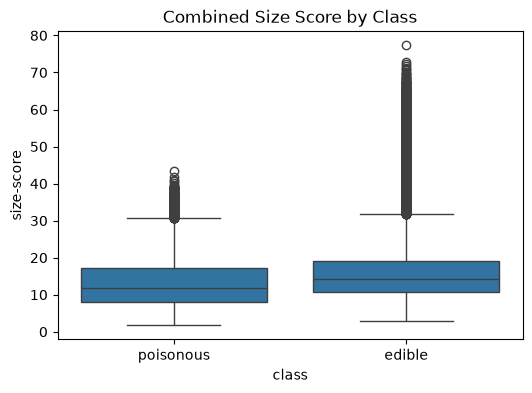

In [28]:
# Engineering 'size-score' (combined size measurements) and check spread by class
df_decoded['size-score'] = df['cap-diameter'] + df['stem-height'] + (df['stem-width']/10) # Divide by 10 to account for unit differences

plt.figure(figsize=(6, 4))
sns.boxplot(data=df_decoded, x='class', y='size-score')
plt.title('Combined Size Score by Class')
plt.show()

## Feature Engineering

Beyond the attributes already present in the dataset, a few engineered features could add predictive value based on patterns found in this analysis report:

**`has-stem` (binary flag):** As identified during our Data Quality investigation, mushrooms with `stem-height` and `stem-width` both equal to 0 were exclusively poisonous. A binary flag capturing stem presence or absence directly encodes this pattern as a single feature rather than relying on a model to learn it from two separate raw measurements.

**`size-score` (composite numeric feature):** Since we found in our analysis that edible mushrooms tend to be consistently larger than poisonous ones across all three numeric dimensions, a combined size metric (cap-diameter + stem-height + scaled stem-width) could capture overall mushroom "size" as a single feature rather than having a model learn this size relationship across independent but correlated variables.

**`cap-shape` + `stem-presence` interaction:** Our investigation into the "others" cap-shape category revealed that it splits into very different subgroups depending on stem presence and size (a stemless, exclusively poisonous subgroup vs. a large-bodied, always-edible subgroup). An interaction feature combining cap-shape with the stem presence feature (`has-stem` binary flag) could capture this conditional pattern more directly and account for the effect that one has on the other.